### Imports

In [253]:
# Imports
import kagglehub
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score

#### Stylise the plots
These settings are taken from Géron's HOML PyTorch

In [254]:
# Make plots look a bit nicer
# Settings taken from Géron's HOML
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

### Separate data for validation
Use sklearn TimeSeriesSplit so that it replicates the actual real world use of the model

## Load data

In [255]:
# Download latest version of Visuelle dataset
path = kagglehub.dataset_download("konradb/visuelle-complete-dataset")

def load_visuelle():
    return pd.read_csv(path + '/train.csv')

df_raw = load_visuelle()
df = df_raw.copy()

In [256]:
def load_test():
    return pd.read_csv(path + '/test.csv')

test_raw = load_test()
test = test_raw.copy()

## Initial Data Analysis

In [257]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,external_code,day,week,month,year
count,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000,5080.000000
mean,0.014884,0.051102,0.058264,0.056137,0.054268,0.053161,0.050315,0.046183,0.041616,0.037107,0.030973,0.027149,2540.500000,0.526575,0.499440,0.535105,0.999445
std,0.023272,0.050550,0.052228,0.050573,0.050793,0.054166,0.056004,0.057796,0.055524,0.055351,0.048515,0.048246,1466.614014,0.284090,0.282472,0.281798,0.000409
min,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000939,0.000000,0.000000,0.000000,-0.001878,-0.000939,0.000000,1.000000,0.000000,0.019231,0.083333,0.998514
25%,0.002817,0.017840,0.022535,0.021596,0.021596,0.019718,0.018779,0.015962,0.012207,0.009390,0.006573,0.004695,1270.750000,0.333333,0.230769,0.250000,0.999009
50%,0.006573,0.037559,0.044131,0.044131,0.041315,0.037559,0.033803,0.030047,0.025352,0.021596,0.016901,0.014085,2540.500000,0.500000,0.538462,0.583333,0.999505
75%,0.017840,0.066667,0.079812,0.074178,0.069484,0.067606,0.061033,0.053521,0.047887,0.043192,0.036620,0.030986,3810.250000,0.666667,0.730769,0.750000,1.000000
max,0.512676,0.763380,0.460094,0.596244,0.628169,0.739906,0.684507,0.998122,0.615962,1.000000,0.921127,0.905164,5080.000000,1.000000,1.000000,1.000000,1.000000


In [258]:
print("Shape:", df.shape)
print ("Columns:", df.columns)

df.info()

Shape: (5080, 24)
Columns: Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11',
       'external_code', 'season', 'category', 'release_date', 'day', 'week',
       'month', 'year', 'image_path', 'color', 'fabric', 'extra'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5080 entries, 0 to 5079
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   0              5080 non-null   float64
 1   1              5080 non-null   float64
 2   2              5080 non-null   float64
 3   3              5080 non-null   float64
 4   4              5080 non-null   float64
 5   5              5080 non-null   float64
 6   6              5080 non-null   float64
 7   7              5080 non-null   float64
 8   8              5080 non-null   float64
 9   9              5080 non-null   float64
 10  10             5080 non-null   float64
 11  11             5080 non-null   float64
 12  external_c

In [259]:
float_cols = df.select_dtypes(include='float64').columns

# Check for any values outside of normalisation range
df[float_cols].describe().T[['min', 'max']]

,min,max
0,0.000000,0.512676
1,0.000000,0.763380
2,0.000000,0.460094
3,0.000000,0.596244
4,0.000000,0.628169
5,-0.000939,0.739906
6,0.000000,0.684507
7,0.000000,0.998122
8,0.000000,0.615962
9,-0.001878,1.000000


In [260]:
# Remove outlying values
df[float_cols] = df[float_cols].clip(0, 1)

df[float_cols].describe().T[['min', 'max']]

,min,max
0,0.000000,0.512676
1,0.000000,0.763380
2,0.000000,0.460094
3,0.000000,0.596244
4,0.000000,0.628169
5,0.000000,0.739906
6,0.000000,0.684507
7,0.000000,0.998122
8,0.000000,0.615962
9,0.000000,1.000000


In [261]:
# Will reuse week_cols and weeks
weeks = range(12)
week_cols = [f"W{w + 1:02d}" for w in weeks]

# Rename weekly columns for ease of read
df = df.rename(
    columns=dict(zip([str(w) for w in weeks], week_cols)),
    errors="raise"
)


## Exploratory Data Analysis

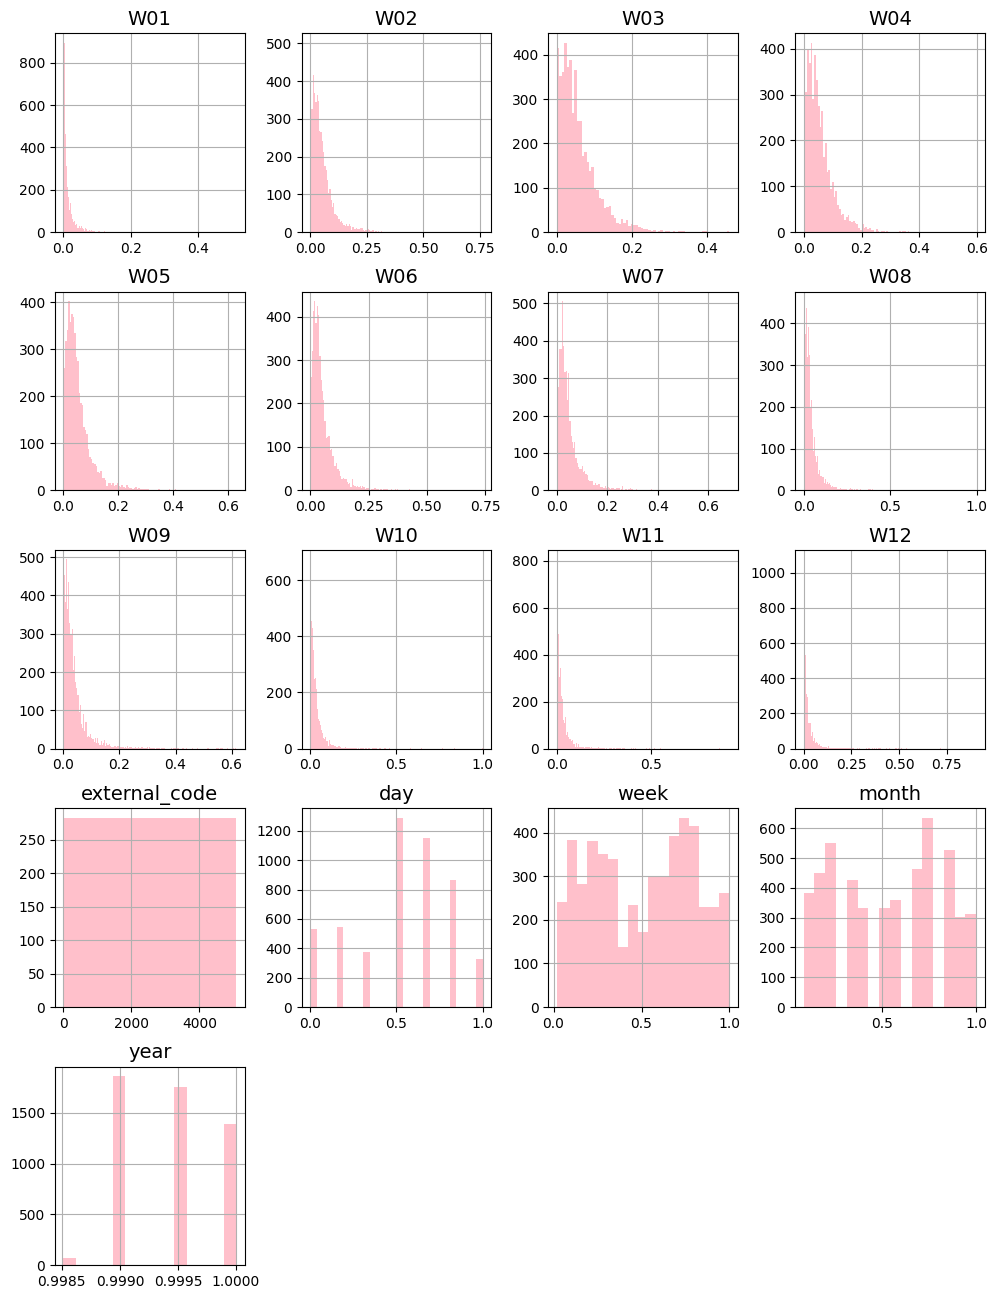

In [262]:
# Histogram for each numerical value
df.hist(bins='auto', figsize=(12, 16), color='pink')
plt.title('Histogram for numerical values')
plt.show()

### Get a better idea of what the data looks like across the 12 weeks

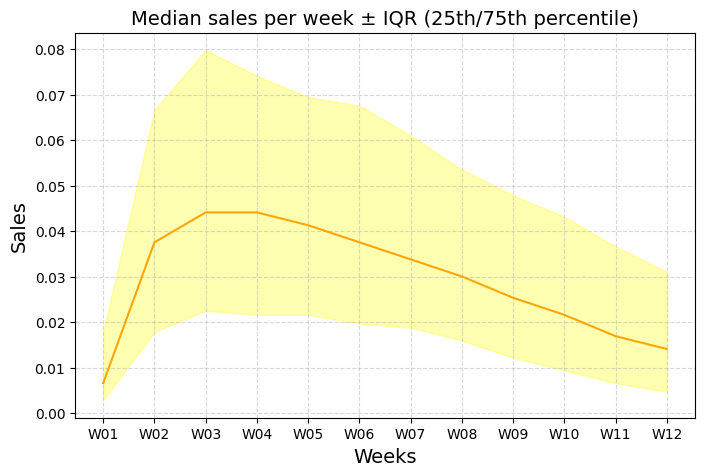

In [263]:
# Plot sales across the 12 weeks
# Interquartile range (25–75)
# IQR = Q₃ - Q₁
# Shows the range of the middle 50% of the dataset
median_sales = df[week_cols].median()

q1 = df[week_cols].quantile(0.25)
q3 = df[week_cols].quantile(0.75)

plt.figure(figsize=(8, 5))

plt.plot(weeks, median_sales, color='orange', label='Median')
plt.fill_between(weeks, q1, q3, alpha=0.3, color='yellow', label='IQR (25th-75th)')

plt.xlabel('Weeks')
plt.xticks(weeks, week_cols)
plt.ylabel('Sales')
plt.title('Median sales per week ± IQR (25th/75th percentile)')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Deciles plots
Split the data into sales deciles and plot each decile's sales across the 12 weeks
This is intended to give me a better idea of the differences in sales across the whole product performance spectrum
And also the amount of products that belongs in each decile

In [264]:
df['sales_total'] = df[week_cols].sum(axis=1)

# Split into 10s
df['decile'] = pd.qcut(df['sales_total'], 10, labels=False, retbins=False, precision=3, duplicates='raise')

# Check split was successful
print(df['decile'].value_counts())

decile
2    510
6    509
0    509
4    508
9    508
5    508
8    508
7    507
1    507
3    506
Name: count, dtype: int64


In [265]:
# Print table of the means
decile_means = df.groupby('decile')[week_cols].mean()
print(decile_means)

             W01       W02       W03       W04       W05       W06       W07  \
decile                                                                         
0       0.004658  0.008676  0.008816  0.007991  0.007172  0.006661  0.006434   
1       0.007991  0.018314  0.019741  0.018105  0.016972  0.015749  0.015574   
2       0.009997  0.025630  0.026632  0.026396  0.024989  0.023553  0.022014   
3       0.011448  0.032135  0.034768  0.033560  0.031506  0.029574  0.027262   
4       0.014195  0.040814  0.044117  0.042444  0.039705  0.036823  0.032936   
5       0.014210  0.048848  0.055443  0.051188  0.047597  0.044189  0.039716   
6       0.018279  0.055978  0.065289  0.061166  0.056030  0.053128  0.049549   
7       0.018322  0.067322  0.078573  0.075658  0.070491  0.068578  0.060772   
8       0.018055  0.079960  0.099898  0.097375  0.094154  0.090681  0.080908   
9       0.031698  0.133409  0.149445  0.147568  0.154142  0.162750  0.168047   

             W08       W09       W10   

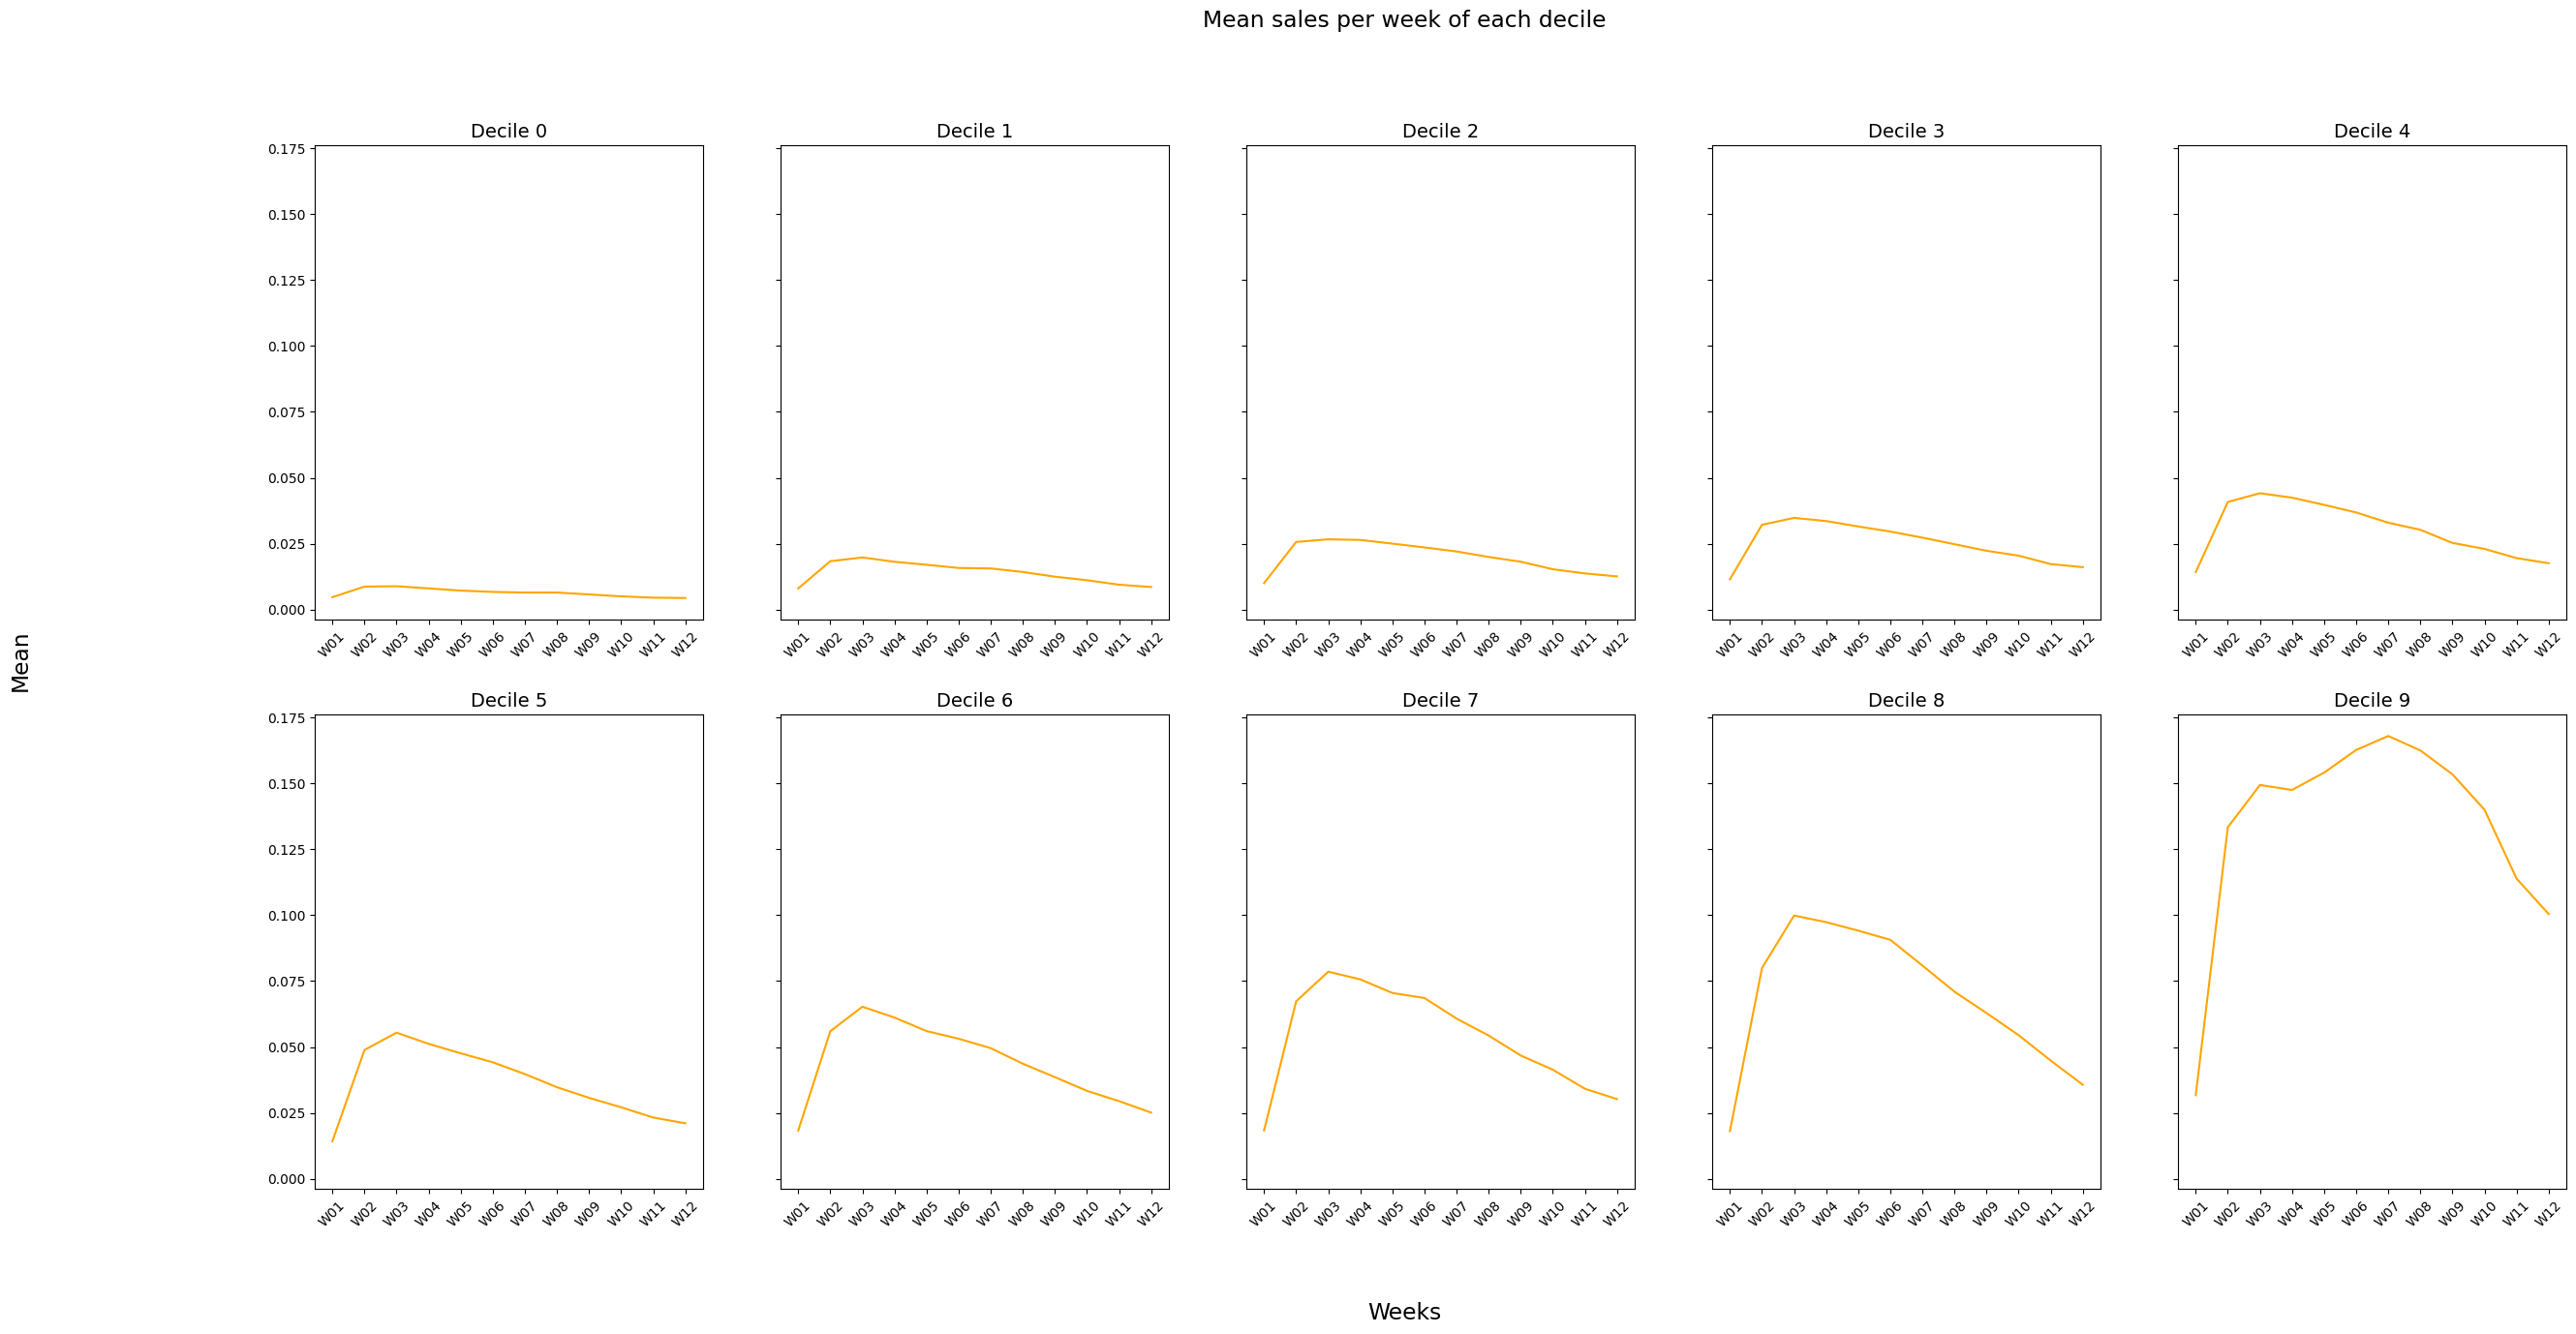

In [266]:
# Prepare and get plots
fig, axes = plt.subplots(2, 5, sharey=True, figsize=(30, 14))

for decile, ax in zip(decile_means.index, axes.flat):
    ax.plot(weeks, decile_means.loc[decile], color='orange')
    ax.set_xticks(weeks, week_cols)
    ax.set_title(f'Decile {decile}')
    ax.tick_params(axis='x', rotation=45)

fig.supxlabel('Weeks')
fig.supylabel('Mean')
fig.suptitle('Mean sales per week of each decile')
plt.show()

Check that the averaging is not smoothing over variation within a decile,
do the median + IQR but per decile

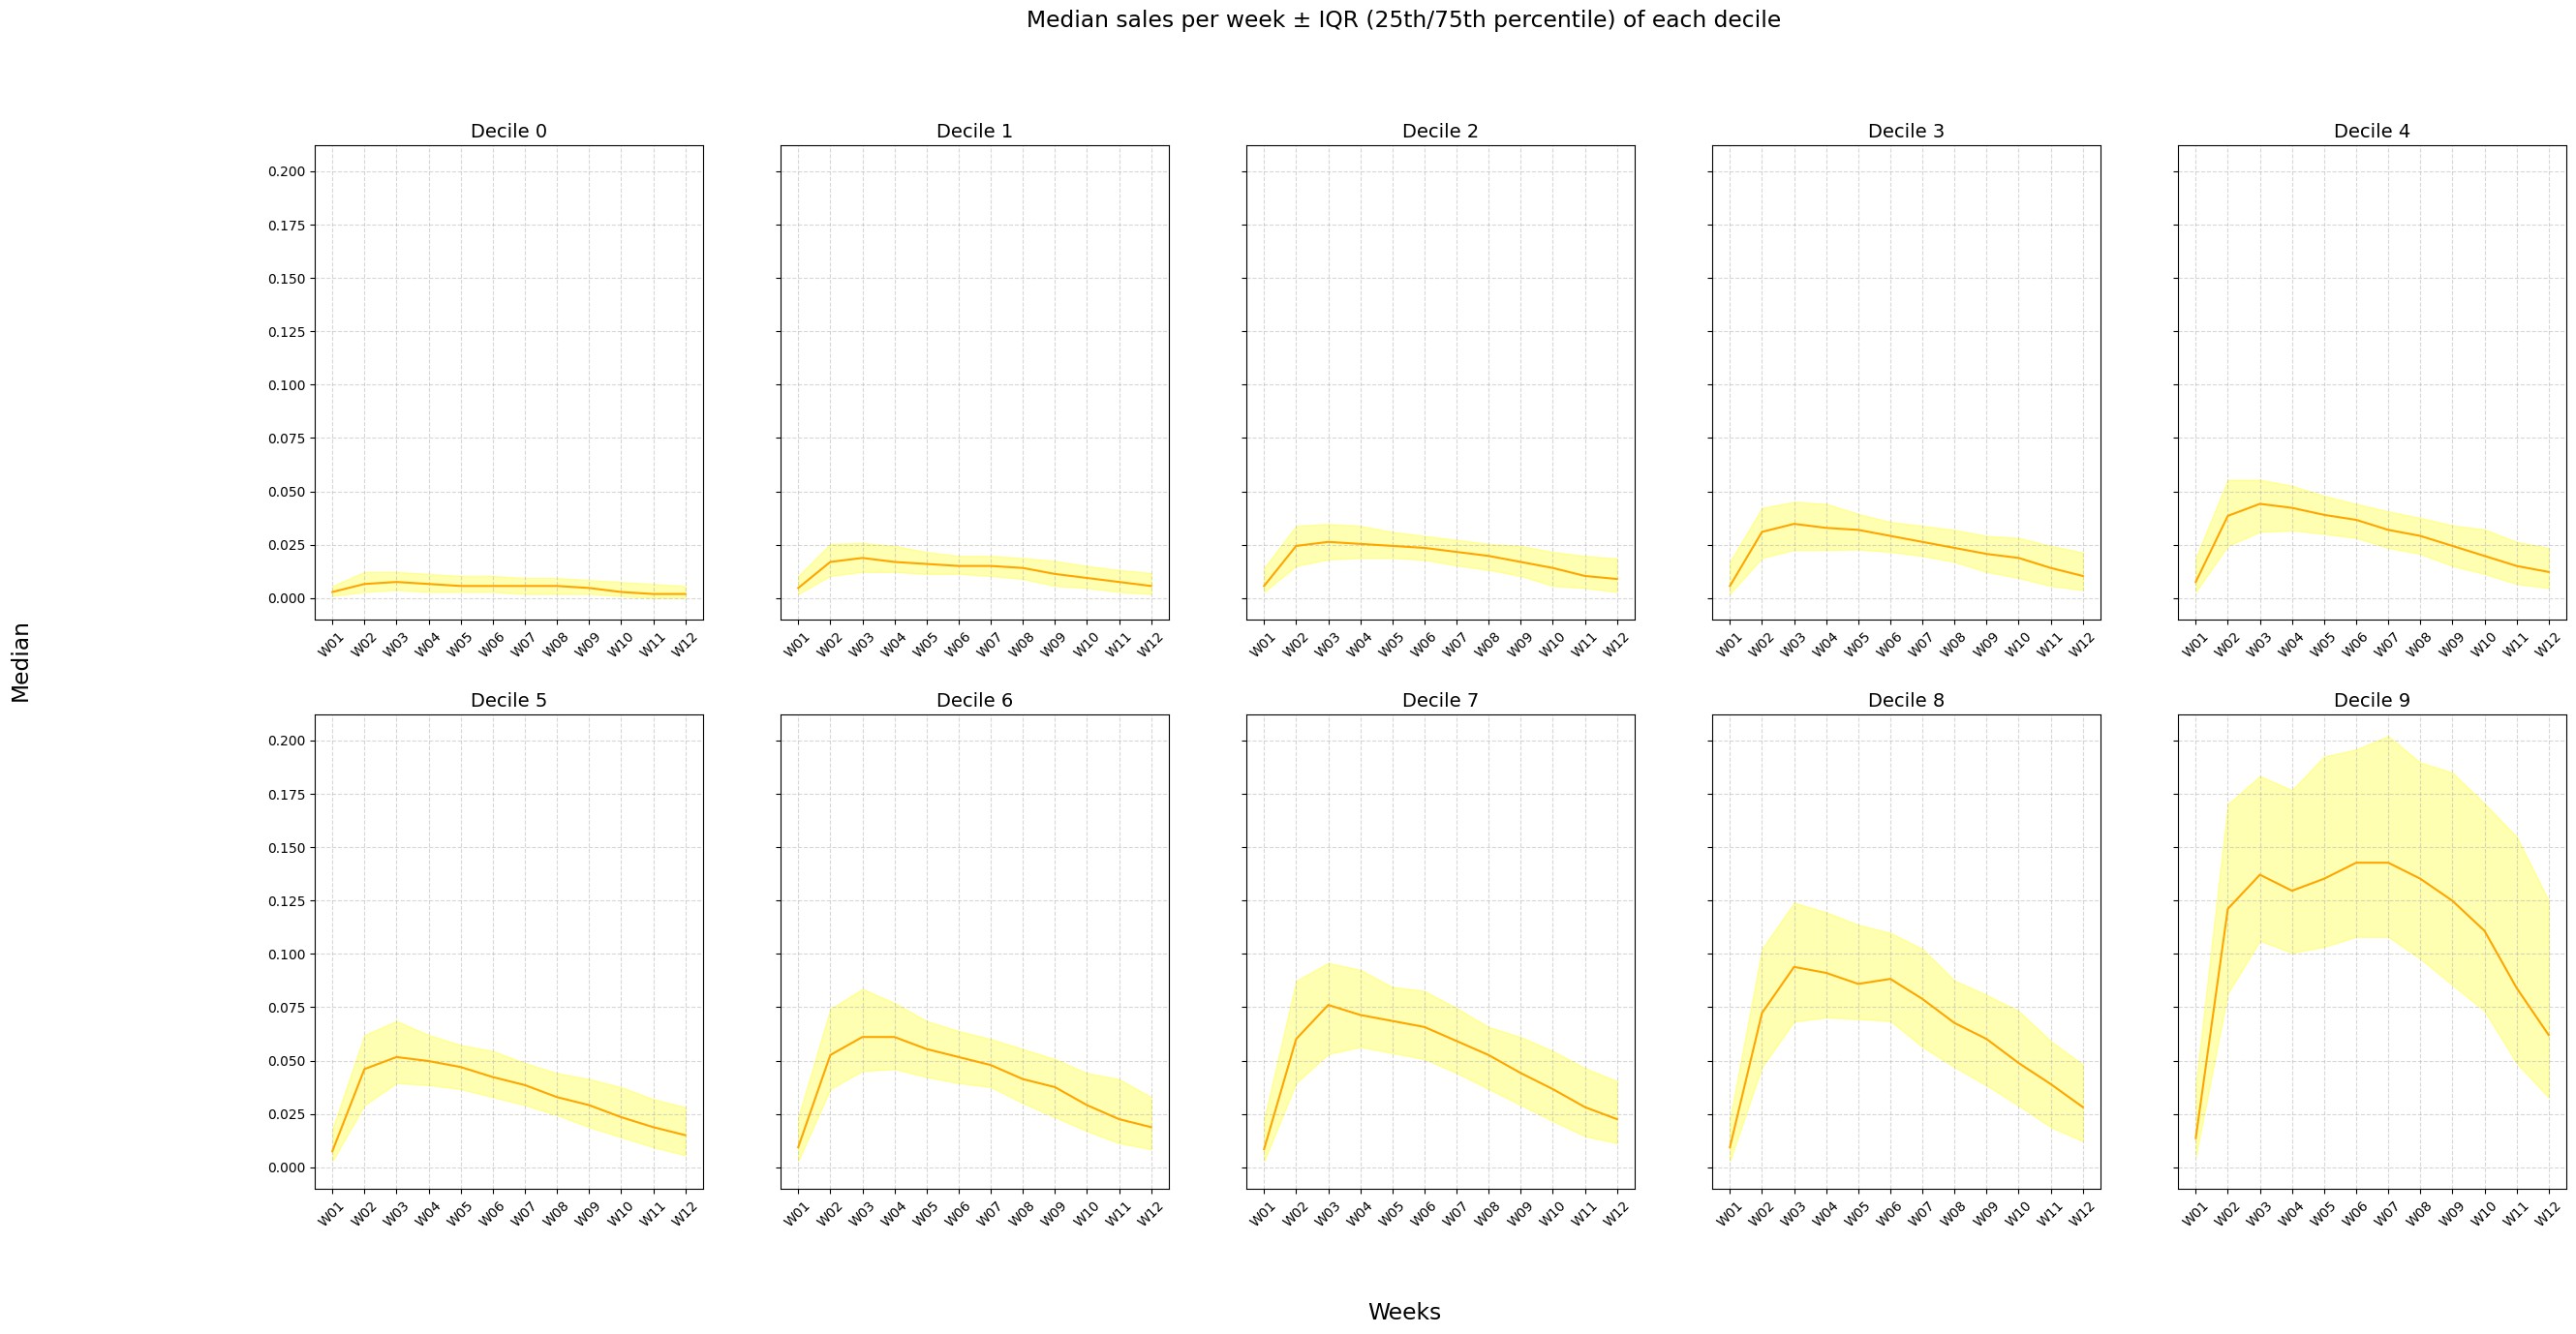

In [267]:
decile_medians = df.groupby('decile')[week_cols].median()
decile_q1 = df.groupby('decile')[week_cols].quantile(0.25)
decile_q3 = df.groupby('decile')[week_cols].quantile(0.75)

fig, axes = plt.subplots(2, 5, sharey=True, figsize=(30, 14))

for decile, ax in zip(decile_medians.index, axes.flat):
    ax.plot(weeks, decile_medians.loc[decile], color='orange')
    ax.fill_between(weeks, decile_q1.loc[decile], decile_q3.loc[decile], alpha=0.3, color='yellow')
    ax.set_xticks(weeks, week_cols)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_title(f'Decile {decile}')

fig.supxlabel('Weeks')
fig.supylabel('Median')
fig.suptitle('Median sales per week ± IQR (25th/75th percentile) of each decile')
plt.show()

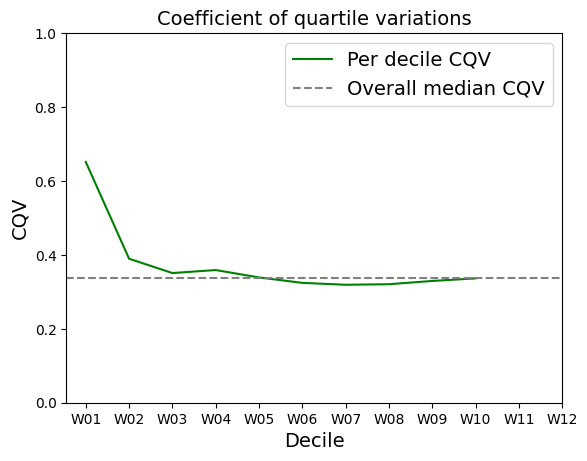

In [268]:
# Check if the larger variation in the higher deciles is due to heteroscedasticity.
# Coefficient of quartile variation
# (Q3−Q1) / (Q3 + Q1)
 
long = (df.reset_index(names='product')
          .melt(id_vars=['product', 'decile'],
                value_vars=week_cols, var_name='week', value_name='sales'))

q = long.groupby(['decile', 'week'])['sales'].quantile([.25, .5, .75]).unstack()
q.columns = ['q1', 'med', 'q3']
q['qcd'] = (q.q3 - q.q1) / (q.q3 + q.q1)

per_decile = q.groupby('decile')['qcd'].median()
spread = q.groupby('decile')['qcd'].agg(['min', 'max'])

plt.plot(per_decile.index, per_decile, color='green', label='Per decile CQV')
plt.axhline(per_decile.median(), color='grey', linestyle='--', label='Overall median CQV')
plt.ylim(0, 1)

plt.xlabel('Decile')
plt.ylabel('CQV')
plt.xticks(weeks, week_cols)
plt.title('Coefficient of quartile variations')
plt.legend()
plt.show()

### Season and Category counts
Do an initial rough split of the data (in thirds) to check if any category or season is particularly overrepresented;

In [269]:
# Split into 3rds
df['thirds'] = pd.qcut(df['sales_total'], 3, labels=['flat', 'slow', 'fast'], retbins=False, precision=3, duplicates='raise')

# Check split was successful
print(df['thirds'].value_counts())

print(df.loc[df['thirds'] == 'flat', 'sales_total'].head(10))
print(df.loc[df['thirds'] == 'slow', 'sales_total'].head(10))
print(df.loc[df['thirds'] == 'fast', 'sales_total'].head(10))

thirds
flat    1696
fast    1694
slow    1690
Name: count, dtype: int64
10    0.125822
12    0.217840
13    0.103286
14    0.184038
16    0.246009
17    0.210329
18    0.271362
19    0.152113
21    0.215962
22    0.217840
Name: sales_total, dtype: float64
0     0.387793
3     0.323944
7     0.424413
9     0.415023
20    0.319249
34    0.314554
37    0.293897
43    0.399061
54    0.366197
57    0.320188
Name: sales_total, dtype: float64
1     1.065728
2     0.597183
4     0.646948
5     1.255399
6     0.575587
8     0.597183
11    0.859155
15    0.786854
51    0.553991
55    0.745540
Name: sales_total, dtype: float64


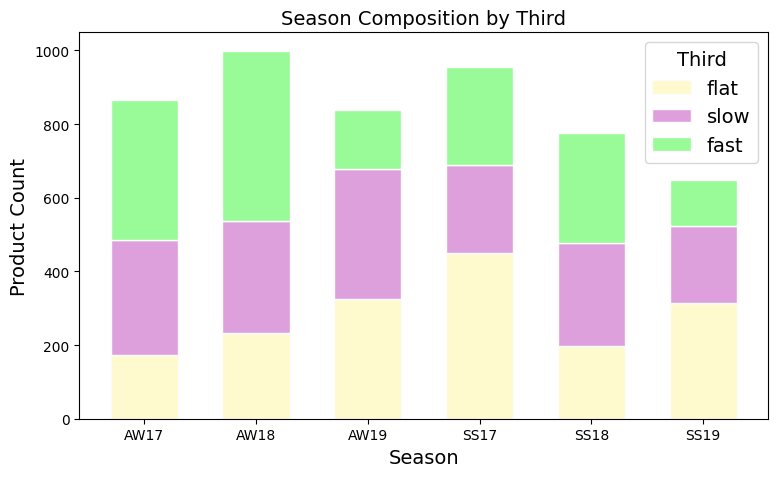

In [270]:
thirds_order = ['flat', 'slow', 'fast']
thirds_colors = {'flat': '#FFFACD', 'slow': '#DDA0DD', 'fast': '#98FB98'}

seasons = sorted(df['season'].unique())
counts = df.groupby(['season', 'thirds'], observed=True).size().unstack(fill_value=0).reindex(columns=thirds_order)

fig, ax = plt.subplots(figsize=(8, 5))

bottom = np.zeros(len(counts))
for third in thirds_order:
    ax.bar(counts.index, counts[third], bottom=bottom, label=third,
           color=thirds_colors[third], edgecolor='#fcfcfb', linewidth=1, width=0.6)
    bottom += counts[third].values

ax.set_xlabel('Season')
ax.set_ylabel('Product Count')
ax.set_title('Season Composition by Third')
ax.legend(title='Third')

plt.tight_layout()
plt.show()

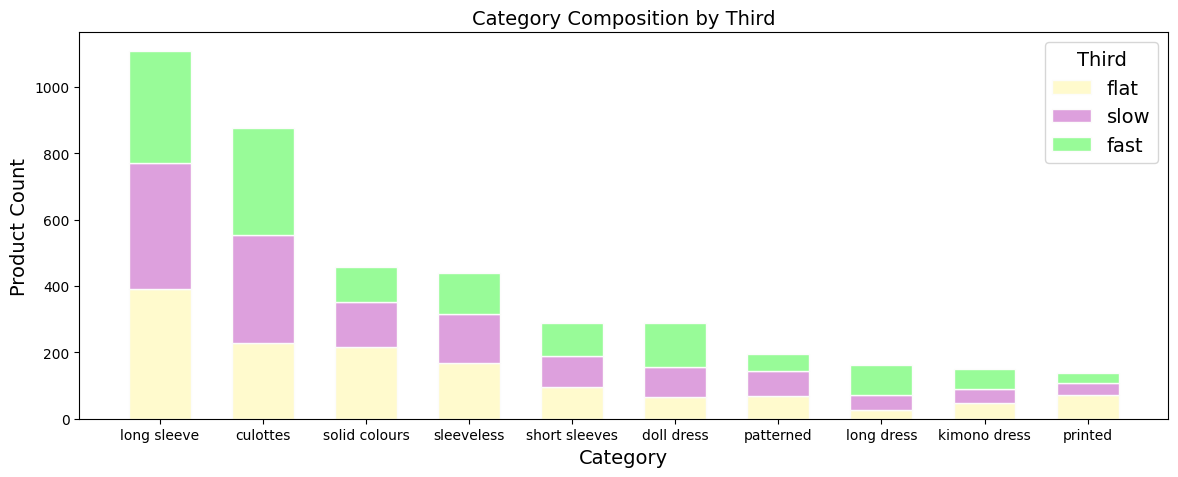

In [271]:
categories = sorted(df['category'].unique())
counts = df.groupby(['category', 'thirds'], observed=True).size().unstack(fill_value=0).reindex(columns=thirds_order)
top_categories = counts.sum(axis=1).nlargest(10).index
counts = counts.loc[top_categories]

fig, ax = plt.subplots(figsize=(12, 5))

bottom = np.zeros(len(counts))
for third in thirds_order:
    ax.bar(counts.index, counts[third], bottom=bottom, label=third,
           color=thirds_colors[third], edgecolor='#fcfcfb', linewidth=1, width=0.6)
    bottom += counts[third].values

ax.set_xlabel('Category')
ax.set_ylabel('Product Count')
ax.set_title('Category Composition by Third')
ax.legend(title='Third')

plt.tight_layout()
plt.show()


In [275]:
# Clean up
columns_to_drop = ['sales_total', 'decile', 'thirds']

df = df.drop(columns=columns_to_drop)

## Build the target feature
Sum first 6-weeks to split the data into their target buckets

In [276]:
# Check how many products had zero sales per week
# Result shows an increase in products as the weeks go on, which helps validate the decision to go with Skenderi's approach and drop weeks 6 to 12
for week in week_cols:
    print(week, (df[week] == 0).sum())

W01 76
W02 95
W03 67
W04 49
W05 37
W06 47
W07 42
W08 67
W09 99
W10 158
W11 265
W12 363


In [286]:
target_weeks = week_cols[:6]

# Measure which I'm building the label against
df['total_sales_6'] = df[target_weeks].sum(axis=1)

# Save to a new file that will contain the target label
df.to_csv('data/train_with_target.csv', index=False)

# Import
csv_filepath = 'data/train_with_target.csv'
df_with_target = pd.read_csv(csv_filepath)

In [291]:
# Write labels for training
# Group: 0–25      | flat | 0
# Group: 37.5–62.5 | slow | 1
# Group: 75–100    | fast | 2

print(df_with_target['total_sales_6'].quantile(0.25))
print(df_with_target['total_sales_6'].quantile(0.375))
print(df_with_target['total_sales_6'].quantile(0.625))
print(df_with_target['total_sales_6'].quantile(0.75))

0.1239436619718307
0.172769953051643
0.2938967136150232
0.384976525821596
